In [2]:
%matplotlib inline

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from collections import Counter
from collections import defaultdict

In [3]:
df = pd.read_csv('../dataset/cmi_internet_imputed.csv')


In [4]:
# Basic inspection
df.head()

,Basic_Demos-Age,Basic_Demos-Sex,CGAS-CGAS_Score,Physical-Height,Physical-Weight,Physical-Waist_Circumference,Physical-Diastolic_BP,Fitness_Endurance-Max_Stage,Physical-HeartRate,Physical-Systolic_BP,...,BIA-BIA_Frame_num,BIA-BIA_ICW,BIA-BIA_LDM,BIA-BIA_LST,BIA-BIA_SMM,PAQ_Total,SDS-SDS_Total_T,PreInt_EduHx-computerinternet_hoursday,Fitness_Endurance-Time,sii
0,5.0,0.0,51,46.000000,50.8,26.000000,69,5,87,114,...,1,24.434900,8.895360,38.9177,19.541300,2.12927,60,3,448,2.0
1,9.0,0.0,66,48.000000,46.0,22.000000,75,5,70,122,...,1,21.035200,14.974000,39.4497,15.410700,2.01000,64,0,434,0.0
2,10.0,1.0,71,56.500000,75.6,26.003679,65,5,94,117,...,2,30.424101,32.959842,56.9964,33.418724,2.17000,54,2,453,0.0
3,9.0,0.0,71,56.000000,81.6,26.000000,60,6,97,117,...,2,30.404100,16.779000,58.9338,26.479800,2.45100,45,0,577,1.0
4,18.0,1.0,65,62.206792,77.0,26.000000,68,5,80,116,...,2,28.855800,23.975607,56.9964,33.915114,1.04000,58,1,433,0.0


In [5]:
num_cols = df.select_dtypes(include=np.number).columns.tolist()

print("Number of numerical columns:", len(num_cols))
print(num_cols)

Number of numerical columns: 33
['Basic_Demos-Age', 'Basic_Demos-Sex', 'CGAS-CGAS_Score', 'Physical-Height', 'Physical-Weight', 'Physical-Waist_Circumference', 'Physical-Diastolic_BP', 'Fitness_Endurance-Max_Stage', 'Physical-HeartRate', 'Physical-Systolic_BP', 'FGC-FGC_CU', 'FGC-FGC_GSND', 'FGC-FGC_GSD', 'FGC-FGC_PU', 'FGC-FGC_SRL', 'FGC-FGC_SRR', 'FGC-FGC_TL', 'BIA-BIA_DEE', 'BIA-BIA_Activity_Level_num', 'BIA-BIA_BMC', 'BIA-BIA_BMR', 'BIA-BIA_ECW', 'BIA-BIA_Fat', 'BIA-BIA_Frame_num', 'BIA-BIA_ICW', 'BIA-BIA_LDM', 'BIA-BIA_LST', 'BIA-BIA_SMM', 'PAQ_Total', 'SDS-SDS_Total_T', 'PreInt_EduHx-computerinternet_hoursday', 'Fitness_Endurance-Time', 'sii']


In [6]:
# remove sii from num_cols
num_cols.remove('sii')


In [7]:
# remove categorical columns from num_cols
cat_cols = df.select_dtypes(include='object').columns.tolist()
print("Number of categorical columns:", len(cat_cols))
print(cat_cols)

Number of categorical columns: 0
[]


In [9]:
# Create a dataframe containing only the numerical predictors

# We exclude the target variable 'sii', which you already removed from num_cols

X_num = df[num_cols].copy()

print("Shape of X_num:", X_num.shape)

print("Number of numerical predictors:", len(num_cols))

Shape of X_num: (8460, 32)
Number of numerical predictors: 32



## Box Plots

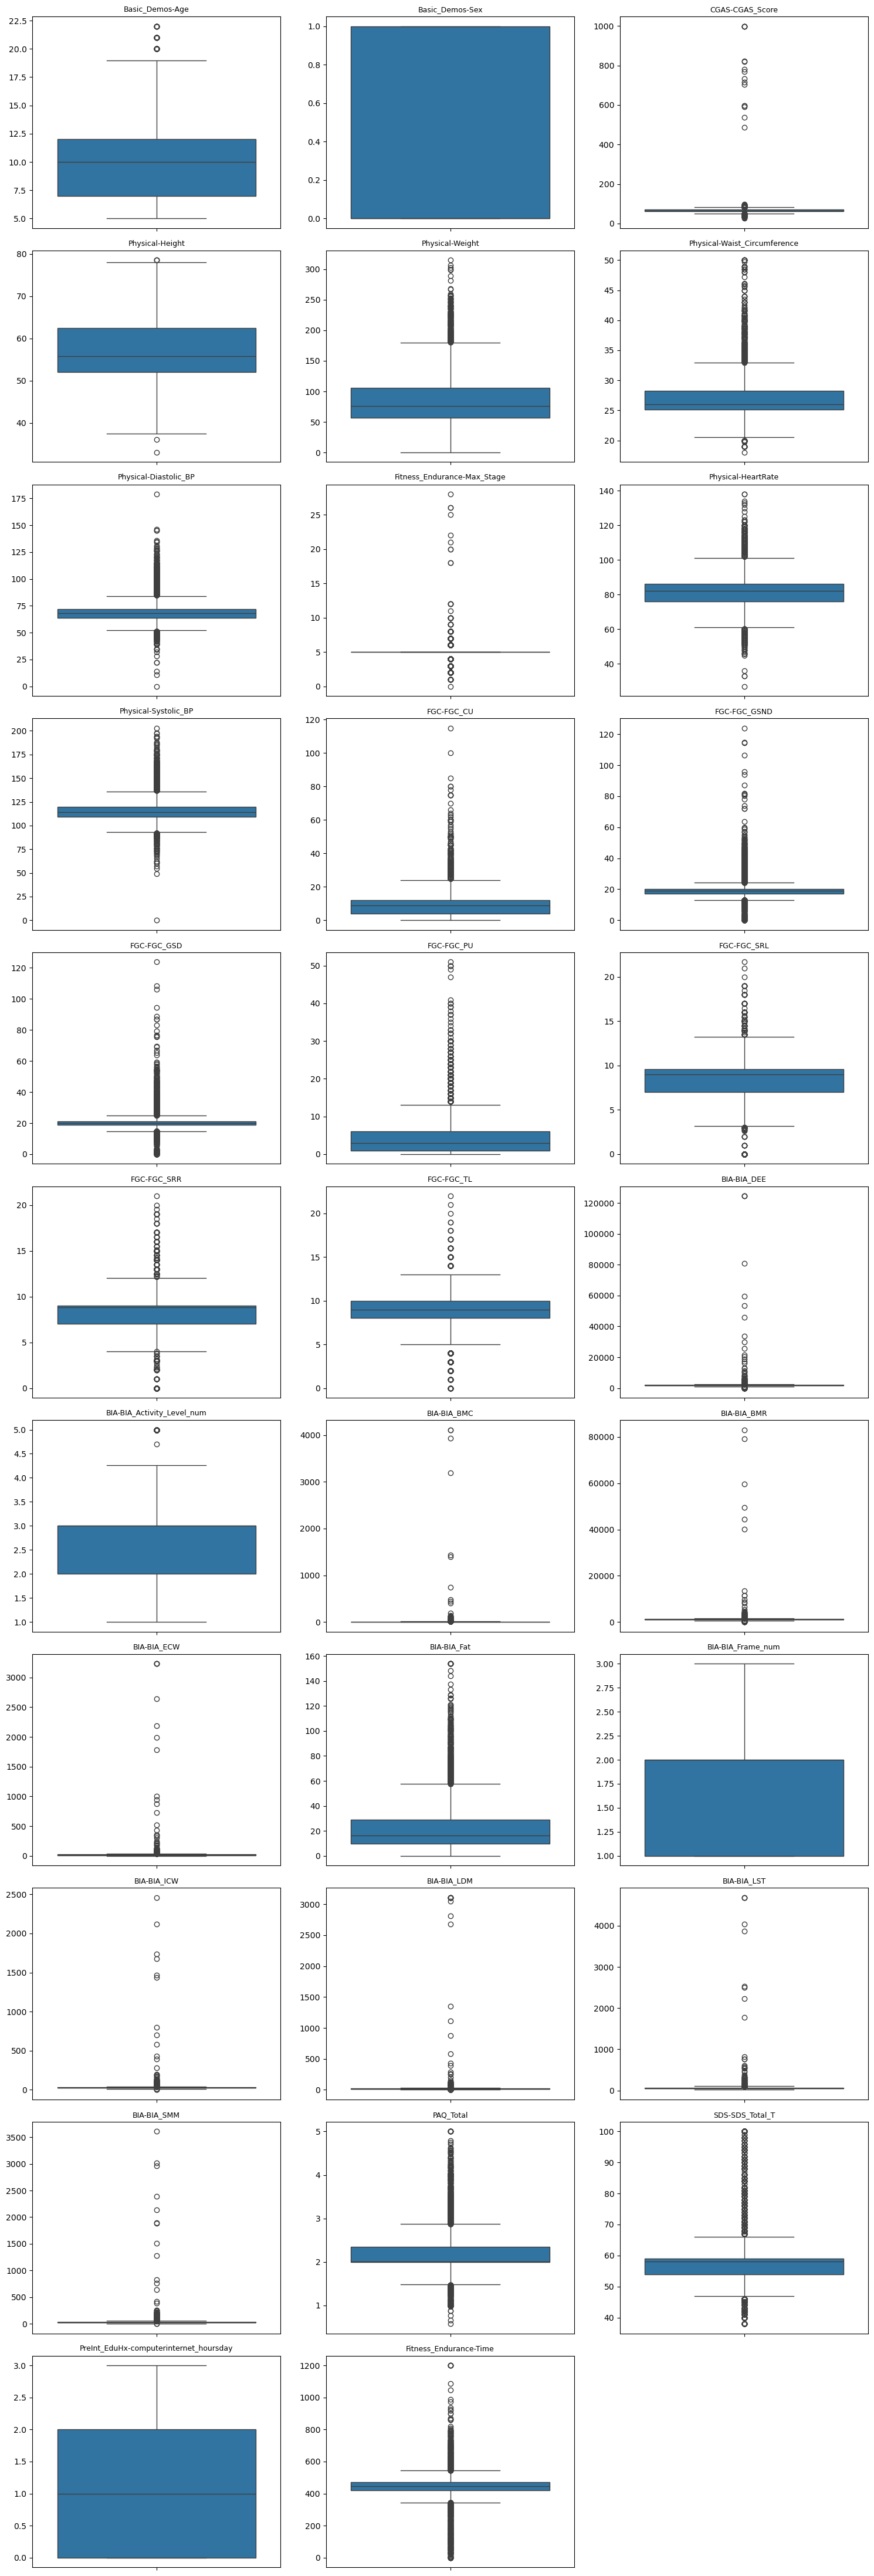

In [11]:
# Boxplots for all numerical predictors

n_cols = 3
n_rows = int(np.ceil(len(num_cols) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4 * n_rows))

axes = axes.ravel()

for i, col in enumerate(num_cols):
    sns.boxplot(y=df[col], ax=axes[i])
    axes[i].set_title(col, fontsize=9)
    axes[i].set_xlabel("")
    axes[i].set_ylabel("")

# Delete unused axes
for j in range(len(num_cols), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [12]:
def iqr_outlier_mask(data, columns, k=1.5):
    """
    Detects univariate outliers using the IQR rule.

    Parameters
    ----------
    data : pandas DataFrame
        Dataset containing the variables to analyze.

    columns : list
        Numerical columns on which the IQR rule is applied.

    k : float, default=1.5
        Multiplicative factor for the IQR rule.
        Standard boxplot rule uses k=1.5.

    Returns
    -------
    outlier_mask : pandas DataFrame
        Boolean DataFrame with the same index as data and one column per variable.
        True means that the value is an outlier for that variable.

    bounds : pandas DataFrame
        DataFrame containing Q1, Q3, IQR, lower bound and upper bound for each variable.
    """

    outlier_mask = pd.DataFrame(False, index=data.index, columns=columns)
    bounds = {}

    for col in columns:
        Q1 = data[col].quantile(0.25)
        Q3 = data[col].quantile(0.75)
        IQR = Q3 - Q1

        lower_bound = Q1 - k * IQR
        upper_bound = Q3 + k * IQR

        outlier_mask[col] = (data[col] < lower_bound) | (data[col] > upper_bound)

        bounds[col] = {
            "Q1": Q1,
            "Q3": Q3,
            "IQR": IQR,
            "lower_bound": lower_bound,
            "upper_bound": upper_bound
        }

    bounds = pd.DataFrame(bounds).T

    return outlier_mask, bounds

In [13]:
# Apply IQR outlier detection

iqr_mask, iqr_bounds = iqr_outlier_mask(X_num, num_cols, k=1.5)

iqr_bounds

,Q1,Q3,IQR,lower_bound,upper_bound
Basic_Demos-Age,7.000000,12.000000,5.000000,-0.500000,19.500000
Basic_Demos-Sex,0.000000,1.000000,1.000000,-1.500000,2.500000
CGAS-CGAS_Score,62.000000,70.000000,8.000000,50.000000,82.000000
Physical-Height,51.990000,62.500000,10.510000,36.225000,78.265000
Physical-Weight,56.600000,106.100000,49.500000,-17.650000,180.350000
Physical-Waist_Circumference,25.100000,28.250000,3.150000,20.375000,32.975000
Physical-Diastolic_BP,64.000000,72.000000,8.000000,52.000000,84.000000
Fitness_Endurance-Max_Stage,5.000000,5.000000,0.000000,5.000000,5.000000
Physical-HeartRate,76.000000,86.000000,10.000000,61.000000,101.000000
Physical-Systolic_BP,109.000000,120.000000,11.000000,92.500000,136.500000


In [ ]:
outliers_per_variable = iqr_mask.sum().sort_values(ascending=False)

outliers_per_variable

Fitness_Endurance-Max_Stage               2624
FGC-FGC_GSD                               1901
PAQ_Total                                 1737
SDS-SDS_Total_T                           1713
FGC-FGC_GSND                              1526
Fitness_Endurance-Time                     951
FGC-FGC_SRR                                764
Physical-Systolic_BP                       729
Physical-Diastolic_BP                      724
BIA-BIA_ICW                                717
FGC-FGC_TL                                 619
CGAS-CGAS_Score                            606
BIA-BIA_DEE                                606
Physical-HeartRate                         596
FGC-FGC_PU                                 566
BIA-BIA_BMC                                565
BIA-BIA_LST                                498
BIA-BIA_SMM                                492
Physical-Waist_Circumference               470
FGC-FGC_CU                                 451
BIA-BIA_LDM                                448
BIA-BIA_BMR  

In [14]:
# Summary of IQR outliers by variable

iqr_summary = iqr_bounds.copy()

iqr_summary["n_outliers"] = iqr_mask.sum(axis=0)
iqr_summary["perc_outliers"] = iqr_mask.mean(axis=0) * 100

iqr_summary = iqr_summary.sort_values("n_outliers", ascending=False)

iqr_summary

,Q1,Q3,IQR,lower_bound,upper_bound,n_outliers,perc_outliers
Fitness_Endurance-Max_Stage,5.000000,5.000000,0.000000,5.000000,5.000000,2624,31.016548
FGC-FGC_GSD,18.700000,21.259550,2.559550,14.860676,25.098874,1901,22.470449
PAQ_Total,2.000000,2.349250,0.349250,1.476125,2.873125,1737,20.531915
SDS-SDS_Total_T,54.000000,59.000000,5.000000,46.500000,66.500000,1713,20.248227
FGC-FGC_GSND,17.299703,20.157728,2.858025,13.012666,24.444765,1526,18.037825
Fitness_Endurance-Time,420.000000,470.000000,50.000000,345.000000,545.000000,951,11.241135
FGC-FGC_SRR,7.000000,9.000000,2.000000,4.000000,12.000000,764,9.030733
Physical-Systolic_BP,109.000000,120.000000,11.000000,92.500000,136.500000,729,8.617021
Physical-Diastolic_BP,64.000000,72.000000,8.000000,52.000000,84.000000,724,8.557920
BIA-BIA_ICW,24.656880,32.503073,7.846193,12.887590,44.272363,717,8.475177


In [15]:
# Keep only variables with at least one outlier

iqr_summary_outliers = iqr_summary[iqr_summary["n_outliers"] > 0]

iqr_summary_outliers

,Q1,Q3,IQR,lower_bound,upper_bound,n_outliers,perc_outliers
Fitness_Endurance-Max_Stage,5.000000,5.000000,0.000000,5.000000,5.000000,2624,31.016548
FGC-FGC_GSD,18.700000,21.259550,2.559550,14.860676,25.098874,1901,22.470449
PAQ_Total,2.000000,2.349250,0.349250,1.476125,2.873125,1737,20.531915
SDS-SDS_Total_T,54.000000,59.000000,5.000000,46.500000,66.500000,1713,20.248227
FGC-FGC_GSND,17.299703,20.157728,2.858025,13.012666,24.444765,1526,18.037825
Fitness_Endurance-Time,420.000000,470.000000,50.000000,345.000000,545.000000,951,11.241135
FGC-FGC_SRR,7.000000,9.000000,2.000000,4.000000,12.000000,764,9.030733
Physical-Systolic_BP,109.000000,120.000000,11.000000,92.500000,136.500000,729,8.617021
Physical-Diastolic_BP,64.000000,72.000000,8.000000,52.000000,84.000000,724,8.557920
BIA-BIA_ICW,24.656880,32.503073,7.846193,12.887590,44.272363,717,8.475177


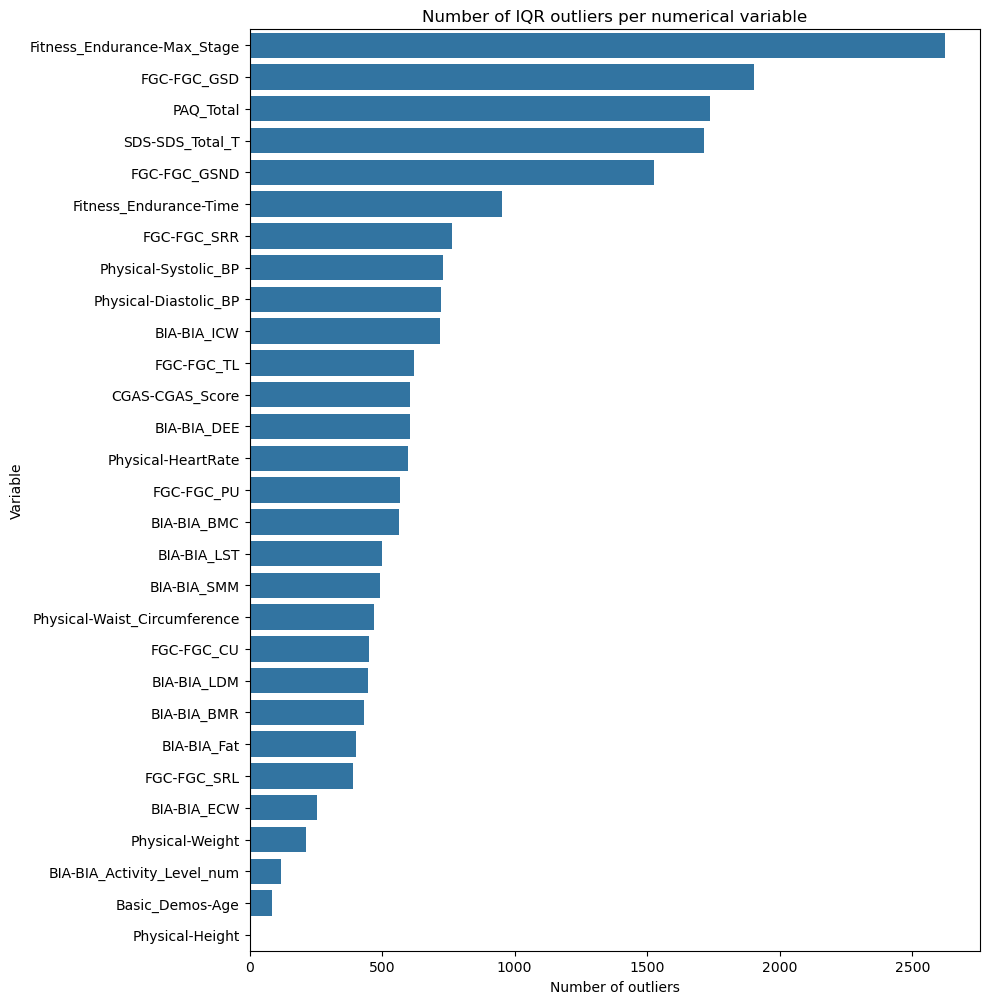

In [16]:
# Plot number of IQR outliers per variable

iqr_summary_plot = iqr_summary_outliers.reset_index().rename(columns={"index": "variable"})

plt.figure(figsize=(10, max(6, 0.35 * len(iqr_summary_plot))))

sns.barplot(

    data=iqr_summary_plot,

    x="n_outliers",

    y="variable"

)

plt.title("Number of IQR outliers per numerical variable")

plt.xlabel("Number of outliers")

plt.ylabel("Variable")

plt.tight_layout()

plt.show()

In [17]:
# Count in how many variables each observation is an IQR outlier

df["iqr_outlier_count"] = iqr_mask.sum(axis=1)

df["iqr_outlier_count"].value_counts().sort_index()

iqr_outlier_count
0     1655
1     1757
2     1711
3     1194
4      801
5      475
6      302
7      183
8      110
9       91
10      59
11      58
12      27
13      21
14       3
15       8
16       3
17       1
20       1
Name: count, dtype: int64

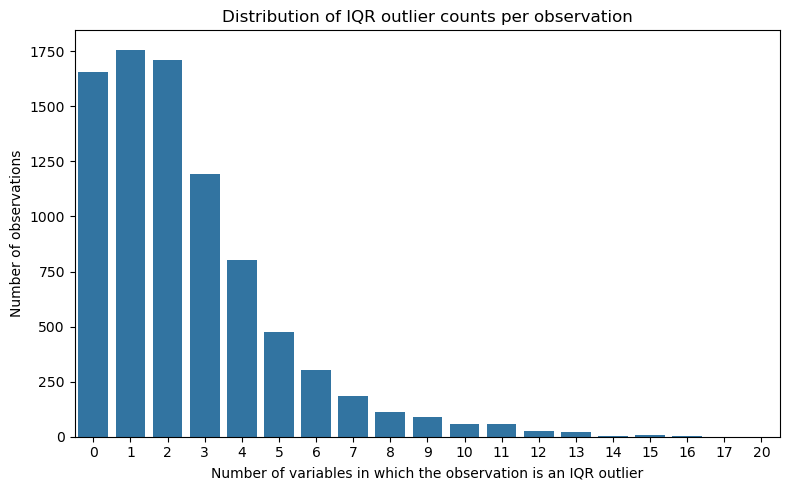

In [18]:
# Plot the distribution of the number of IQR outlier variables per observation

plt.figure(figsize=(8, 5))

sns.countplot(x=df["iqr_outlier_count"])

plt.title("Distribution of IQR outlier counts per observation")
plt.xlabel("Number of variables in which the observation is an IQR outlier")
plt.ylabel("Number of observations")
plt.tight_layout()
plt.show()

In [19]:
# Inspect observations with the highest number of IQR outlier variables

most_suspicious_iqr = df.sort_values("iqr_outlier_count", ascending=False)

most_suspicious_iqr[["iqr_outlier_count"] + num_cols].head(10)

,iqr_outlier_count,Basic_Demos-Age,Basic_Demos-Sex,CGAS-CGAS_Score,Physical-Height,Physical-Weight,Physical-Waist_Circumference,Physical-Diastolic_BP,Fitness_Endurance-Max_Stage,Physical-HeartRate,...,BIA-BIA_Fat,BIA-BIA_Frame_num,BIA-BIA_ICW,BIA-BIA_LDM,BIA-BIA_LST,BIA-BIA_SMM,PAQ_Total,SDS-SDS_Total_T,PreInt_EduHx-computerinternet_hoursday,Fitness_Endurance-Time
489,20,17.0,0.0,70,69.50,240.6,33.721840,100,5,102,...,73.690200,2,72.061600,43.079900,155.277000,97.923100,2.38,45,0,448
1662,17,16.0,0.0,55,71.00,232.0,34.908541,79,4,102,...,72.236600,3,67.245700,41.741400,150.859000,81.746000,1.25,69,2,448
5869,16,17.0,0.0,66,73.36,235.3,34.145141,105,4,76,...,111.367737,2,49.903160,40.042742,118.712126,63.561803,3.00,70,2,463
655,16,20.0,0.0,71,78.50,247.2,36.133274,65,5,59,...,50.910300,3,78.994400,52.527500,198.353000,97.356600,2.54,40,1,472
306,16,16.0,0.0,63,67.50,298.8,49.000000,72,5,93,...,119.986000,3,73.273800,46.759400,171.380000,82.303300,1.38,91,3,420
3774,15,18.0,0.0,71,73.00,238.6,35.977882,106,5,85,...,0.000000,3,138.491000,94.167200,334.766000,215.413000,3.31,59,3,468
3270,15,16.0,0.0,40,73.00,315.0,38.066315,50,5,74,...,129.226000,3,79.473800,50.447900,177.560000,116.019000,1.96,61,3,477
3935,15,15.0,0.0,48,66.00,182.2,39.000000,83,4,102,...,60.653200,3,52.121100,31.168500,115.263000,53.638000,1.12,56,3,420
4800,15,20.0,0.0,64,75.53,157.0,33.100000,80,5,78,...,40.545406,2,46.669258,199.286156,173.643387,64.512163,3.00,76,3,478
1976,15,16.0,0.0,71,69.50,258.0,46.000000,77,5,78,...,104.018000,3,64.234400,41.049500,146.742000,72.464500,1.25,73,2,420


In [20]:
# Inspect which variables make the most suspicious row anomalous

row_idx = most_suspicious_iqr.index[0]

outlier_variables = iqr_mask.loc[row_idx]
outlier_variables = outlier_variables[outlier_variables].index.tolist()

print("Row index:", row_idx)
print("Number of IQR outlier variables:", len(outlier_variables))
print("Outlier variables:")
print(outlier_variables)

Row index: 489
Number of IQR outlier variables: 20
Outlier variables:
['Physical-Weight', 'Physical-Waist_Circumference', 'Physical-Diastolic_BP', 'Physical-HeartRate', 'Physical-Systolic_BP', 'FGC-FGC_GSND', 'FGC-FGC_GSD', 'FGC-FGC_SRL', 'FGC-FGC_SRR', 'BIA-BIA_DEE', 'BIA-BIA_Activity_Level_num', 'BIA-BIA_BMC', 'BIA-BIA_BMR', 'BIA-BIA_ECW', 'BIA-BIA_Fat', 'BIA-BIA_ICW', 'BIA-BIA_LDM', 'BIA-BIA_LST', 'BIA-BIA_SMM', 'SDS-SDS_Total_T']


In [21]:
# Compare different thresholds for defining a global IQR outlier

for threshold in range(1, 8):
    n_flagged = (df["iqr_outlier_count"] >= threshold).sum()
    perc_flagged = n_flagged / len(df) * 100
    
    print(f"At least {threshold} outlier variables: {n_flagged} rows ({perc_flagged:.2f}%)")

At least 1 outlier variables: 6805 rows (80.44%)
At least 2 outlier variables: 5048 rows (59.67%)
At least 3 outlier variables: 3337 rows (39.44%)
At least 4 outlier variables: 2143 rows (25.33%)
At least 5 outlier variables: 1342 rows (15.86%)
At least 6 outlier variables: 867 rows (10.25%)
At least 7 outlier variables: 565 rows (6.68%)


## Automatic Box- Plots

In [24]:
def is_outlier(x, k=1.5):
    """
    Detect outliers in a single numerical variable using the IQR rule.

    Parameters
    ----------
    x : array-like
        One numerical variable.
    k : float
        IQR multiplier. Standard boxplot rule uses k = 1.5.

    Returns
    -------
    outliers : numpy array of booleans
        True means that the corresponding value is an outlier.
    """
    
    q1 = np.quantile(x, 0.25)
    q3 = np.quantile(x, 0.75)
    iqr = q3 - q1
    
    lower_bound = q1 - k * iqr
    upper_bound = q3 + k * iqr
    
    outliers = []
    
    for v in x:
        if v < lower_bound or v > upper_bound:
            outliers.append(True)
        else:
            outliers.append(False)
            
    return np.array(outliers)

In [25]:
iqr_outliers = {}

for col in num_cols:
    outliers = is_outlier(df[col], k=1.5)
    values, counts = np.unique(outliers, return_counts=True)
    
    iqr_outliers[col] = {
        "n_normal": counts[values == False][0] if False in values else 0,
        "n_outliers": counts[values == True][0] if True in values else 0
    }

iqr_outliers_summary = pd.DataFrame(iqr_outliers).T
iqr_outliers_summary = iqr_outliers_summary.sort_values("n_outliers", ascending=False)

iqr_outliers_summary

,n_normal,n_outliers
Fitness_Endurance-Max_Stage,5836,2624
FGC-FGC_GSD,6559,1901
PAQ_Total,6723,1737
SDS-SDS_Total_T,6747,1713
FGC-FGC_GSND,6934,1526
Fitness_Endurance-Time,7509,951
FGC-FGC_SRR,7696,764
Physical-Systolic_BP,7731,729
Physical-Diastolic_BP,7736,724
BIA-BIA_ICW,7743,717


In [26]:
iqr_outliers_summary["perc_outliers"] = (
    iqr_outliers_summary["n_outliers"] / len(df) * 100
)

iqr_outliers_summary

,n_normal,n_outliers,perc_outliers
Fitness_Endurance-Max_Stage,5836,2624,31.016548
FGC-FGC_GSD,6559,1901,22.470449
PAQ_Total,6723,1737,20.531915
SDS-SDS_Total_T,6747,1713,20.248227
FGC-FGC_GSND,6934,1526,18.037825
Fitness_Endurance-Time,7509,951,11.241135
FGC-FGC_SRR,7696,764,9.030733
Physical-Systolic_BP,7731,729,8.617021
Physical-Diastolic_BP,7736,724,8.557920
BIA-BIA_ICW,7743,717,8.475177


In [27]:
iqr_mask = pd.DataFrame(index=df.index)

for col in num_cols:
    iqr_mask[col] = is_outlier(df[col], k=1.5)

iqr_mask.head()

,Basic_Demos-Age,Basic_Demos-Sex,CGAS-CGAS_Score,Physical-Height,Physical-Weight,Physical-Waist_Circumference,Physical-Diastolic_BP,Fitness_Endurance-Max_Stage,Physical-HeartRate,Physical-Systolic_BP,...,BIA-BIA_Fat,BIA-BIA_Frame_num,BIA-BIA_ICW,BIA-BIA_LDM,BIA-BIA_LST,BIA-BIA_SMM,PAQ_Total,SDS-SDS_Total_T,PreInt_EduHx-computerinternet_hoursday,Fitness_Endurance-Time
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,True,False,False,...,False,False,False,False,False,False,False,True,False,True
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,True,False,False,False


### HBOS

In [22]:
 !pip install pyod

In [23]:
from pyod.models.hbos import HBOS
from sklearn.preprocessing import StandardScaler

In [28]:
# Data matrix for HBOS
# We use only numerical predictors, excluding the target variable 'sii'

X_hbos = df[num_cols].copy()

print("Shape of X_hbos:", X_hbos.shape)
print("Number of numerical predictors:", X_hbos.shape[1])

Shape of X_hbos: (8460, 32)
Number of numerical predictors: 32


In [29]:
# Fit HBOS model

clf_hbos = HBOS(
    n_bins=10,
    contamination=0.10
)

clf_hbos.fit(X_hbos)

HBOS(alpha=0.1, contamination=0.1, n_bins=10, tol=0.5)

In [30]:
# HBOS anomaly scores

hbos_scores = clf_hbos.decision_scores_

hbos_scores[:10]

array([74.61689512, 74.90769121, 78.90428448, 80.59166759, 79.61044798,
       81.59971622, 78.72530893, 80.30475978, 74.79612502, 78.50882137])

In [31]:
# HBOS predicted labels

hbos_labels = clf_hbos.labels_

np.unique(hbos_labels, return_counts=True)

(array([0, 1]), array([7614,  846]))

In [33]:
hbos_results = pd.DataFrame({

    "hbos_score": hbos_scores,

    "hbos_outlier": hbos_labels

}, index=df.index)

hbos_results.head()

,hbos_score,hbos_outlier
0,74.616895,0
1,74.907691,0
2,78.904284,0
3,80.591668,0
4,79.610448,0


In [34]:
hbos_results["hbos_outlier"].value_counts()

hbos_outlier
0    7614
1     846
Name: count, dtype: int64

In [35]:
hbos_results["hbos_outlier"].value_counts(normalize=True) * 100

hbos_outlier
0    90.0
1    10.0
Name: proportion, dtype: float64

<Figure size 800x500 with 0 Axes>

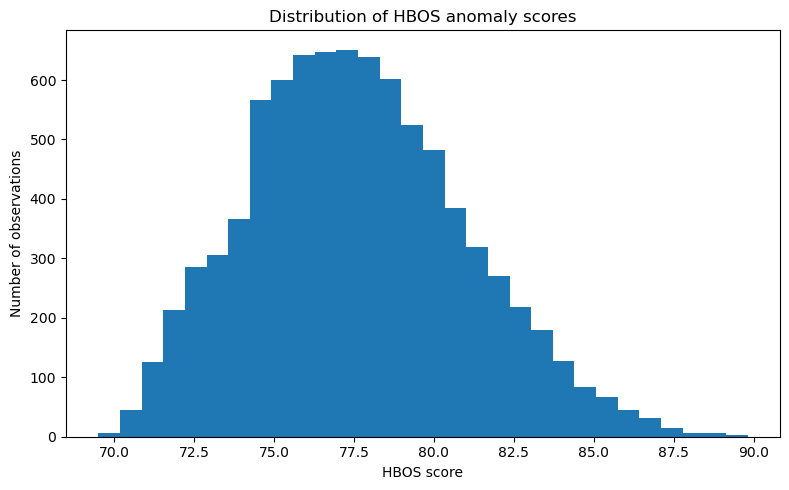

In [36]:
plt.figure(figsize=(8, 5))

plt.hist(hbos_results["hbos_score"], bins=30)

plt.title("Distribution of HBOS anomaly scores")

plt.xlabel("HBOS score")

plt.ylabel("Number of observations")

plt.tight_layout()

plt.show()

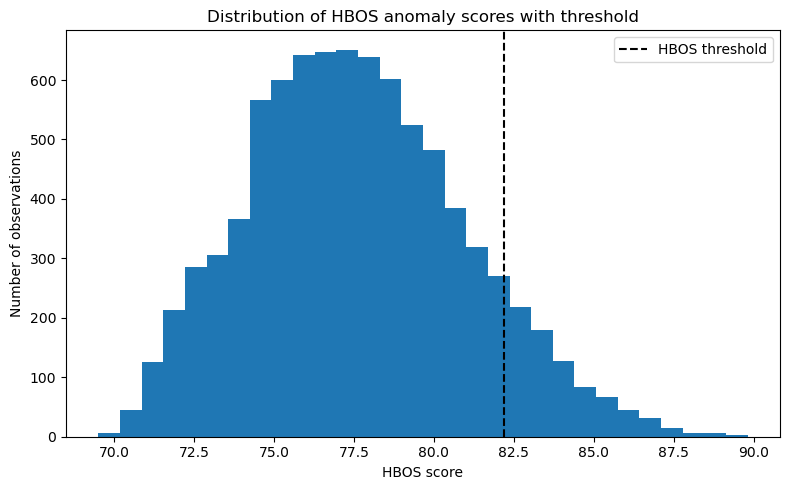

In [37]:
threshold_hbos = clf_hbos.threshold_

plt.figure(figsize=(8, 5))

plt.hist(hbos_results["hbos_score"], bins=30)
plt.axvline(threshold_hbos, color="black", linestyle="--", label="HBOS threshold")

plt.title("Distribution of HBOS anomaly scores with threshold")
plt.xlabel("HBOS score")
plt.ylabel("Number of observations")
plt.legend()
plt.tight_layout()
plt.show()

In [38]:
most_anomalous_hbos = hbos_results.sort_values(
    "hbos_score", 
    ascending=False
)

most_anomalous_hbos.head(10)

,hbos_score,hbos_outlier
87,89.812010,1
586,89.358469,1
3849,89.271063,1
1192,89.107643,1
439,89.100569,1
43,88.917549,1
1031,88.884625,1
59,88.751527,1
3447,88.709641,1
489,88.379469,1


In [42]:
def plot_hbos_scatter(x_var, y_var, df, hbos_results):
    """
    Scatter plot of two numerical variables, colored by HBOS outlier label.
    """

    plot_data = pd.DataFrame({
        x_var: df[x_var],
        y_var: df[y_var],
        "HBOS_label": hbos_results["hbos_outlier"].map({0: "Normal", 1: "Outlier"})
    })

    plt.figure(figsize=(8, 6))

    sns.scatterplot(
        data=plot_data,
        x=x_var,
        y=y_var,
        hue="HBOS_label",
        alpha=0.7
    )

    plt.title(f"HBOS outliers: {x_var} vs {y_var}")
    plt.xlabel(x_var)
    plt.ylabel(y_var)
    plt.tight_layout()
    plt.show()

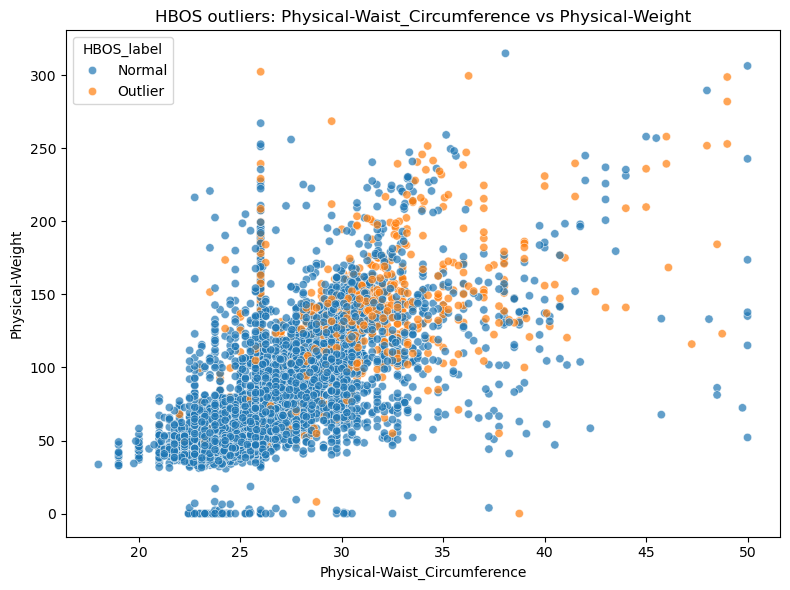

In [43]:
plot_hbos_scatter("Physical-Waist_Circumference", "Physical-Weight", df, hbos_results)

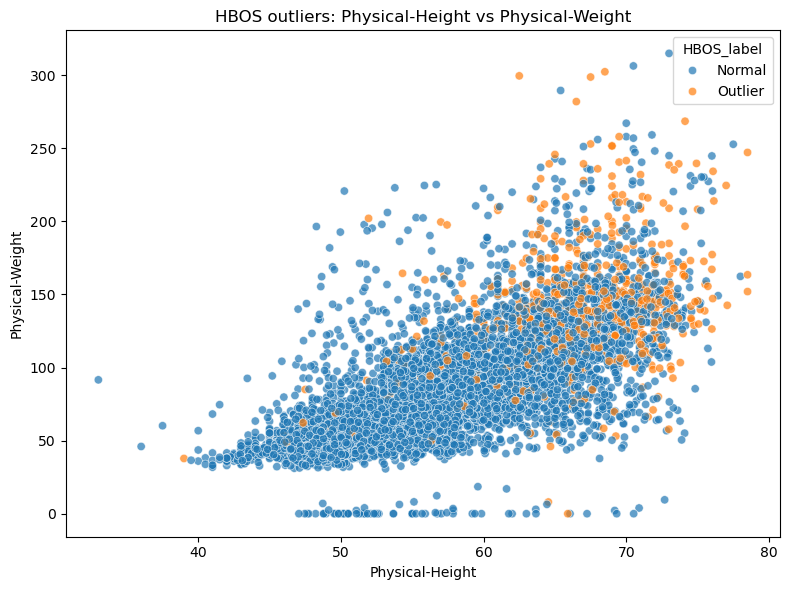

In [44]:
plot_hbos_scatter("Physical-Height", "Physical-Weight", df, hbos_results)

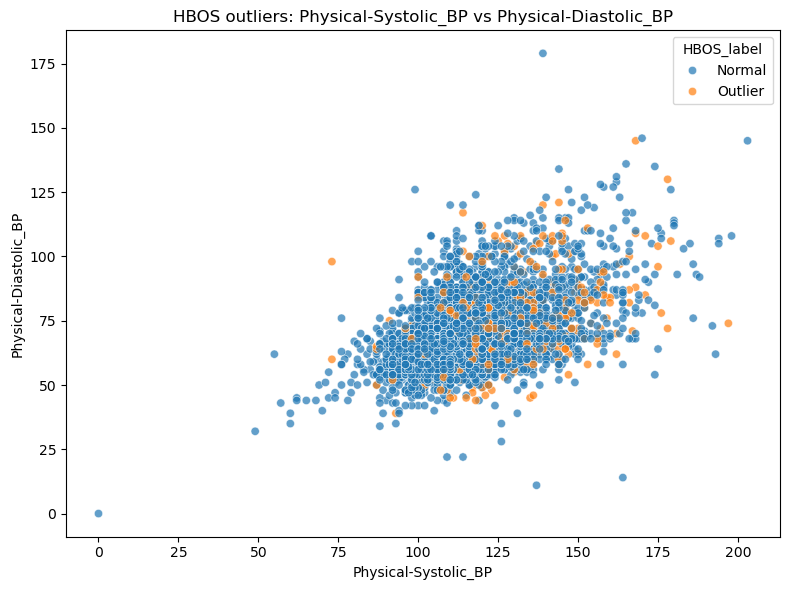

In [45]:
plot_hbos_scatter("Physical-Systolic_BP", "Physical-Diastolic_BP", df, hbos_results)

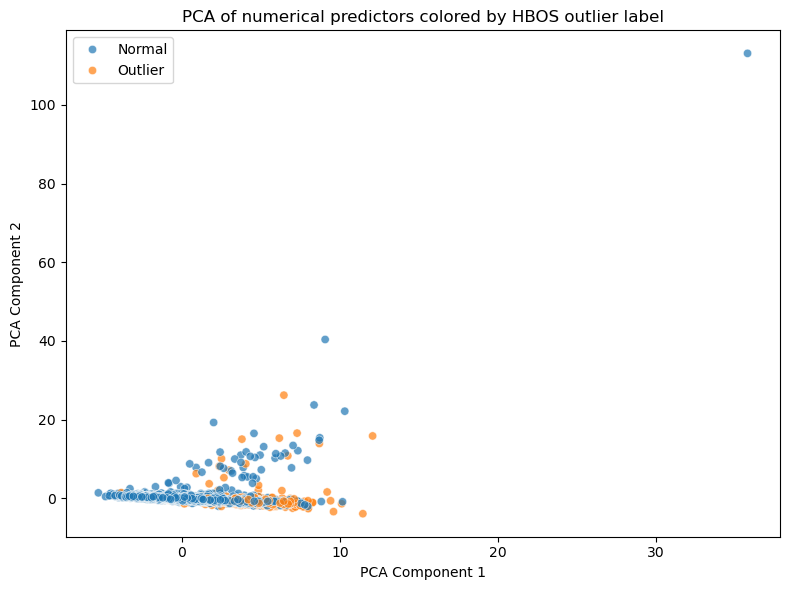

In [54]:
#try to visualize outliers vs normal points through PCA
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
# Standardize the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_hbos)
# Apply PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
# Create a DataFrame for plotting
pca_df = pd.DataFrame({
    "PCA1": X_pca[:, 0],
    "PCA2": X_pca[:, 1],
    "HBOS_label": hbos_results["hbos_outlier"].map({0: "Normal", 1: "Outlier"})
})
# Plot the PCA results
plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=pca_df,
    x="PCA1",
    y="PCA2",
    hue="HBOS_label",
    alpha=0.7
)
plt.title("PCA of numerical predictors colored by HBOS outlier label")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.legend()
plt.tight_layout()
plt.show()

In [55]:
np.unique(hbos_results["hbos_outlier"], return_counts=True)

(array([0, 1]), array([7614,  846]))